# Steane Basic Level Noise (single round)

Data generation and analysis
    + different decoder: ML, MWPM
    + different distances
    + different noise levels

analysis: 
    + show asymptotic behavior
    + determine thresholds


In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tools.file import write_config, smart_read_folder 
from tools.combined import generate_new_data_from_config_file
from tools.analysis import data_pre_processing, determine_threshold, data_plot_log_error_rates, data_plot_fssa_results

## Config Defintions and Data Generation

Steane circ (order 0p) with only 1 QEC round (both log X and Z observable)

Basic noise with different noise levels

Decoding both in ML and MWPM


In [21]:
# General parameter
noise_rates = [float(x) for x in np.logspace(-1.2,-0.8,dtype=float)] # weird choice of noise rate because i need to put it into a yaml file -> might be probelmatic later!
distances = [3,5,7,9,11,13,15] # 3 is newly included! not yet in data!
qec_rounds = [1,]
order = "0p"
circuit_type = "steane"

# Main parameters
num_shots_ML = 1_000
decoder_type_ML = "ml"
# 700 min + for 100_000 data
num_shots_MWPM = 10_000
decoder_type_MWPM = "mwpm"

# Z config
noise_model_type_Z = "bit_flip"
observable_Z  = "Z"
init_state_Z = "0"
# X config
noise_model_type_X = "phase_flip"
observable_X  = "X"
init_state_X = "p"

In [22]:
# Folder names (for writing data to file):
general_name = "md_1r_mp_BN"

In [23]:
# Switches for data generation
regen_data_everything = False 

regen_data_ML = False 
regen_data_MWPM = False 


In [24]:
# ML Config (Z)
# Verbose is better!
config_ML_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type_Z,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_ML, 
    },
    "sampling": {
        "num_shots":    num_shots_ML,       # number of shots per configuration
    },
}
        
# write config to file
config_path = write_config(config_ML_Z, general_name, backup=True, sub_name="ML_Z")

# Generate ML Data
if regen_data_everything or regen_data_ML or False:
    generate_new_data_from_config_file(config_path, output_folder_name = general_name)

In [25]:
# ML Config (X)

config_ML_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type_X,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_ML, 
    },
    "sampling": {
        "num_shots":    num_shots_ML,       # number of shots per configuration
    },
}

# write config to file
config_path = write_config(config_ML_X, general_name, backup=True, sub_name="ML_X")

# Generate ML Data
if regen_data_everything or regen_data_ML or False:
    generate_new_data_from_config_file(config_path, output_folder_name = general_name)

In [26]:
# MWPM Config (Z)

config_MWPM_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type_Z,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,       # number of shots per configuration
    },
}


# write config to file
config_path = write_config(config_MWPM_Z, general_name, backup=True, sub_name="MWPM_Z")

# Generate ML Data
if regen_data_everything or regen_data_MWPM or False:
    generate_new_data_from_config_file(config_path, output_folder_name = general_name)

In [27]:
# MWPM Config (X)

config_MWPM_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type_X,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,     
    },
}

# write config to file
config_path = write_config(config_MWPM_X, general_name, backup=True, sub_name="MWPM_X")

# Generate ML Data
if regen_data_everything or regen_data_MWPM or False:
    generate_new_data_from_config_file(config_path, output_folder_name = general_name)

## Analysis

[toric code](https://errorcorrectionzoo.org/c/toric):

+ toric code: code capacity 
    + MWPM: px = 10.31%
    + ML: 10.94 +- 0.02%

[surface code](https://errorcorrectionzoo.org/c/surface):

[arthur pesah](https://arthurpesah.me/blog/2023-05-13-surface-code/):





In [28]:
# Folder paths (reading in data)
# basic config is given to be able to infer the correct path to the data!
# r_folder_name_ML_Z = "md_1r_mp_BN"
# basic_config_ML_Z = config_ML_Z

# r_folder_name_ML_X = "md_1r_mp_BN"
# basic_config_ML_X = config_ML_X

# r_folder_name_MWPM_Z = "md_1r_mp_BN"
# basic_config_MWPM_Z = config_MWPM_Z

# r_folder_name_MWPM_X = "md_1r_mp_BN"
# basic_config_MWPM_X = config_MWPM_X

r_folder_path_ML_Z =   "/home/fu494742/MasterArbeit/code/data/steane/0p/bit_flip/ml/z/md_1r_mp_BN" 
r_folder_path_ML_X =   "/home/fu494742/MasterArbeit/code/data/steane/0p/phase_flip/ml/x/md_1r_mp_BN" 
r_folder_path_MWPM_Z = "/home/fu494742/MasterArbeit/code/data/steane/0p/bit_flip/mwpm/z/md_1r_mp_BN" 
r_folder_path_MWPM_X = "/home/fu494742/MasterArbeit/code/data/steane/0p/phase_flip/mwpm/x/md_1r_mp_BN" 

lit_p_th_ml = 0.1094
lit_p_th_mwpm = 0.1031

In [29]:
def analysis_pipeline(
        folder_path, 
        # basic_config,
        # folder_name, 
        guess_pth, 
        guess_nu, 
        min_distance: list = None, 
        max_distance: list = None, 
        min_noise_rate: list = None,
        max_noise_rate: list = None,
        p_window: list = None,
        plots = True,
        ):

    if p_window != None:
        if min_noise_rate != None or max_noise_rate != None:
            raise UserWarning("Both p_window and min-/max_noise_rate give! Too much restictions!")
        min_noise_rate = np.array(guess_pth) / p_window
        max_noise_rate = np.array(guess_pth) * p_window

    config, data = smart_read_folder(folder_path=folder_path)#folder_name=folder_name, basic_config=basic_config)
    data = data_pre_processing(data)
    data = determine_threshold(
        data,
        guess_nu=guess_nu,
        guess_pth=guess_pth,
        min_distance=min_distance,
        max_distance=max_distance,
        min_noise_rate=min_noise_rate,
        max_noise_rate=max_noise_rate,
        )
    # complete
    if plots:
        data_plot_log_error_rates(data)
        data_plot_fssa_results(
            data,
            min_distance=min_distance,
            max_distance=max_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
            )
        # around threshold
        data_plot_log_error_rates(
            data,
            min_distance=min_distance,
            max_distance=max_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
        )
    print(f"Num_shots: {data["num_shots"]}")
    print(f"p_th: {data["p_th"]}")
    print(f"nu_fit: {data["nu_fit"]}")
    return data

### Generate analysis Data

In [30]:
# General fit parameters: 
g_pth_ml = [0.108]
g_pth_mwpm = [0.103]

g_nu = [1.5]

p_window = [10**(0.1)]
min_distance = [5]


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.8536390665319943
             x: [ 1.052e-01  6.733e-01]
           nit: 48
          nfev: 99
 final_simplex: (array([[ 1.052e-01,  6.733e-01],
                       [ 1.052e-01,  6.733e-01],
                       [ 1.052e-01,  6.733e-01]]), array([ 8.536e-01,  8.536e-01,  8.536e-01]))
[0.10524931]
[0.01096203]


<Figure size 640x480 with 0 Axes>

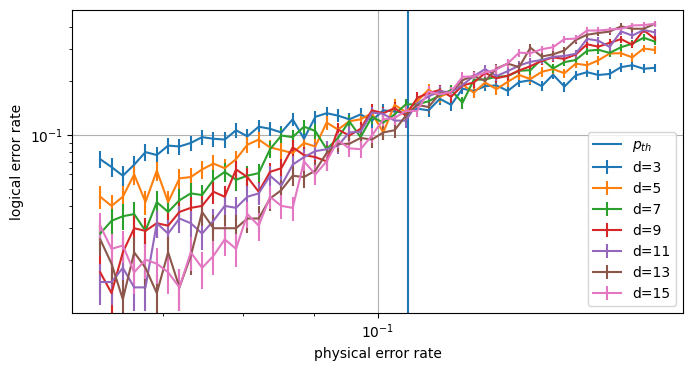

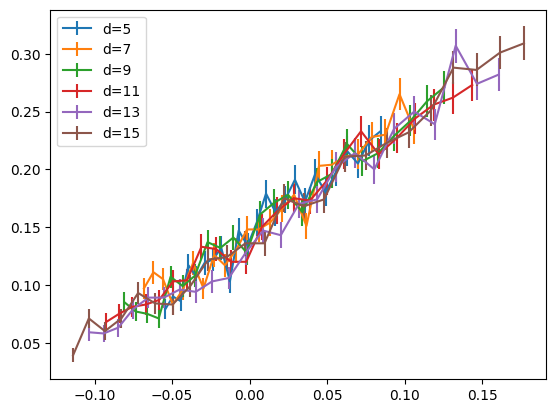

<Figure size 640x480 with 0 Axes>

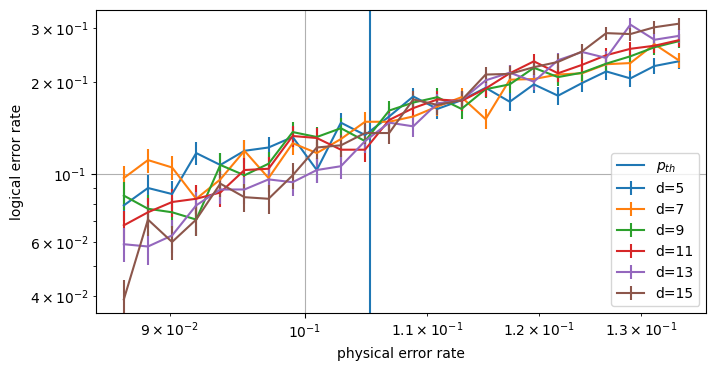

Num_shots: 1000
p_th: [0.10524931]
nu_fit: [1.4851469]


In [31]:
# ML Z
result = analysis_pipeline(
    folder_path=    r_folder_path_ML_Z,
    guess_pth =     g_pth_ml,
    guess_nu =      g_nu,
    min_distance=   min_distance, 
    p_window =      p_window,
    )

results_ML_Z = result


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.9484312534744986
             x: [ 1.070e-01  6.891e-01]
           nit: 77
          nfev: 148
 final_simplex: (array([[ 1.070e-01,  6.891e-01],
                       [ 1.070e-01,  6.891e-01],
                       [ 1.070e-01,  6.891e-01]]), array([ 9.484e-01,  9.484e-01,  9.484e-01]))
[0.10700236]
[0.01110854]


<Figure size 640x480 with 0 Axes>

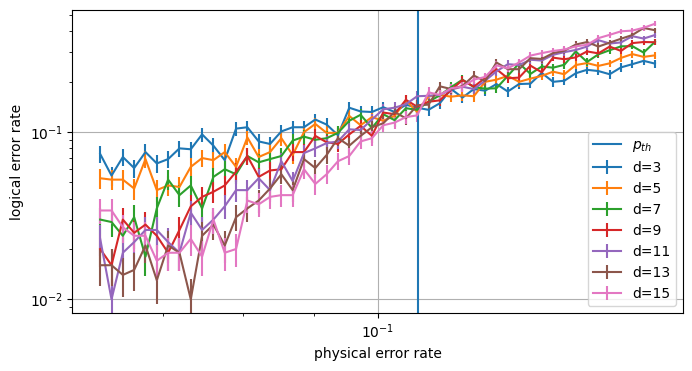

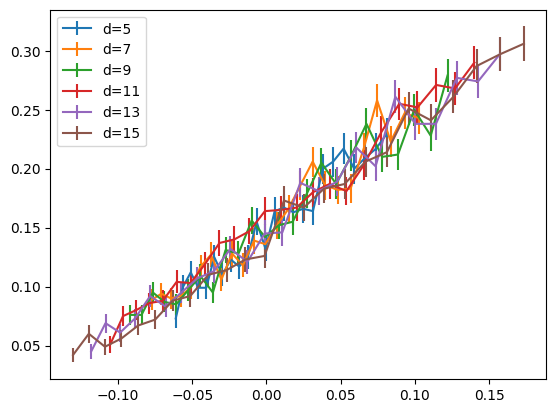

<Figure size 640x480 with 0 Axes>

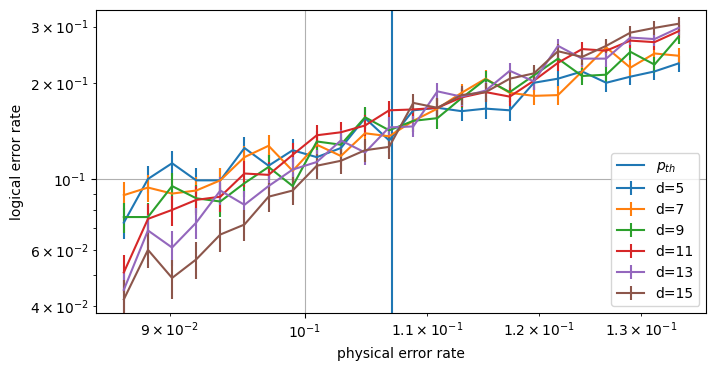

Num_shots: 1000
p_th: [0.10700236]
nu_fit: [1.45116362]


In [32]:
# ML X
result = analysis_pipeline(
    folder_path=    r_folder_path_ML_X,
    guess_pth =     g_pth_ml,
    guess_nu =      g_nu,
    min_distance=   min_distance, 
    p_window =      p_window,
    )

results_ML_X = result


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.8791577813136787
             x: [ 1.027e-01  6.799e-01]
           nit: 33
          nfev: 67
 final_simplex: (array([[ 1.027e-01,  6.799e-01],
                       [ 1.027e-01,  6.798e-01],
                       [ 1.027e-01,  6.799e-01]]), array([ 8.792e-01,  8.792e-01,  8.792e-01]))
[0.10270043]
[0.00308227]


<Figure size 640x480 with 0 Axes>

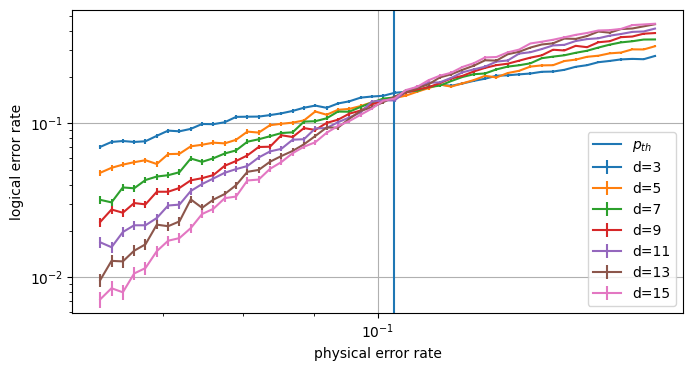

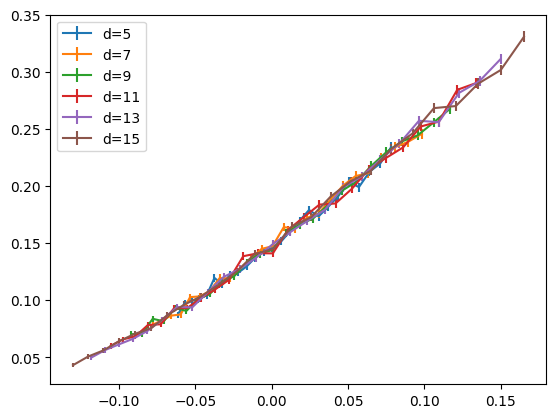

<Figure size 640x480 with 0 Axes>

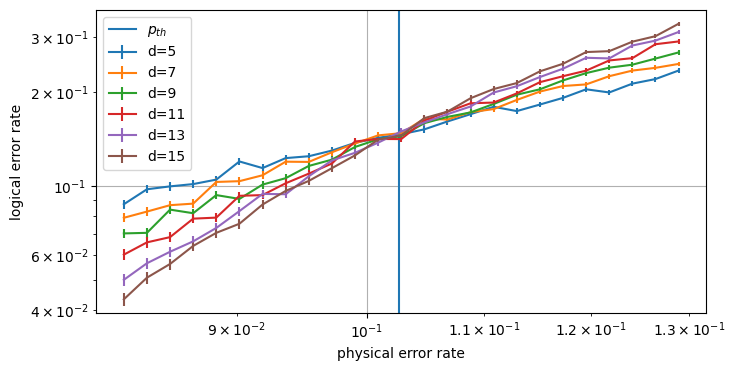

Num_shots: 10000
p_th: [0.10270043]
nu_fit: [1.47090424]


In [33]:
# MWPM Z 
result = analysis_pipeline(
    folder_path=    r_folder_path_MWPM_Z,
    guess_pth =     g_pth_mwpm,
    guess_nu =      g_nu,
    min_distance=   min_distance, 
    p_window =      p_window,
    )

results_MWPM_Z = result


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.090375484243297
             x: [ 1.028e-01  6.956e-01]
           nit: 117
          nfev: 240
 final_simplex: (array([[ 1.028e-01,  6.956e-01],
                       [ 1.028e-01,  6.956e-01],
                       [ 1.028e-01,  6.956e-01]]), array([ 1.090e+00,  1.090e+00,  1.090e+00]))
[0.102788]
[0.0036227]


<Figure size 640x480 with 0 Axes>

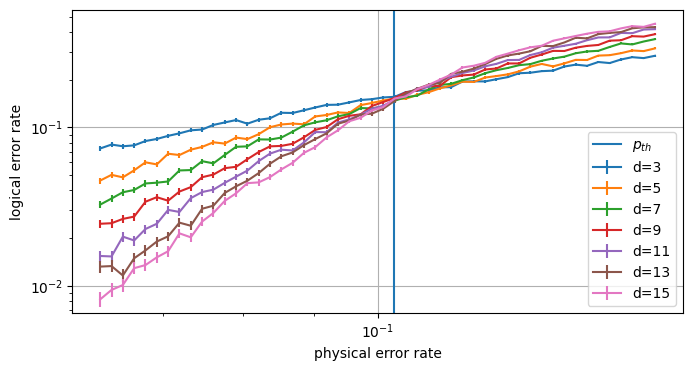

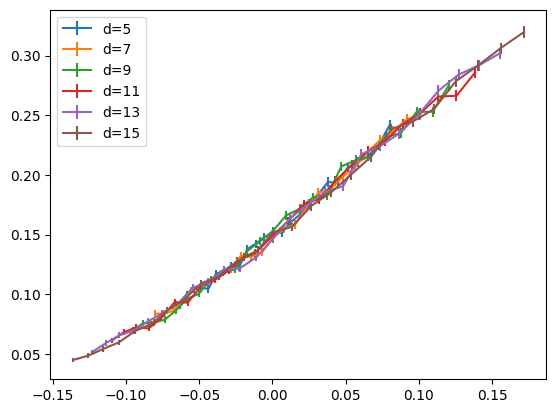

<Figure size 640x480 with 0 Axes>

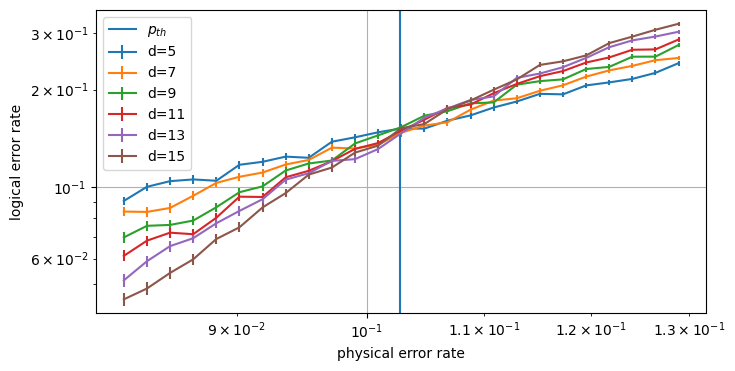

Num_shots: 10000
p_th: [0.102788]
nu_fit: [1.43760593]


In [34]:
# MWPM X 
result = analysis_pipeline(
    folder_path=    r_folder_path_MWPM_X,
    guess_pth =     g_pth_mwpm,
    guess_nu =      g_nu,
    min_distance=   min_distance, 
    p_window =      p_window,
    )

results_MWPM_X = result

## Thresholds Results (1 round flip noise)

In [35]:
# collection of all threshold:
results = [results_ML_Z, results_ML_X, results_MWPM_Z, results_MWPM_X]
names = ["ML Z", "ML X", "MWPM Z", "MWPM X"]
literature = [lit_p_th_ml] * 2 + [lit_p_th_mwpm] * 2

for i in range(len(names)):
    print(f"For {names[i]}: threshold = {results[i]["p_th"][0]*10**2:.3f} +- {results[i]["err_p_th"][0]*10**2:.3f} %(literatur: {literature[i]*10**2:.3f}%)")



For ML Z: threshold = 10.525 +- 1.096 %(literatur: 10.940%)
For ML X: threshold = 10.700 +- 1.111 %(literatur: 10.940%)
For MWPM Z: threshold = 10.270 +- 0.308 %(literatur: 10.310%)
For MWPM X: threshold = 10.279 +- 0.362 %(literatur: 10.310%)


Results fit to expectation MWPM threshold is lower than ML threshold.

Both lay within range of the literature (Scale up to get smaller eroors)

## Varying parameters

In [36]:


# as collections
folder_names = [r_folder_path_ML_Z, r_folder_path_ML_X, r_folder_path_MWPM_Z, r_folder_path_MWPM_X]
names = ["ML Z", "ML X", "MWPM Z", "MWPM X"]

g_pths = [g_pth_ml] *2  + [g_pth_mwpm]*2

g_nus = [g_nu] * 4

In [37]:
# Varying distance
min_distances = [5,7,9]
window_distance = 2*3 

p_th_varied = np.zeros((len(min_distances), len(folder_names)))
err_p_th_varied = np.zeros((len(min_distances), len(folder_names)))
nu_fit_varied = np.zeros((len(min_distances), len(folder_names))) 

for j in range(len(min_distances)):
    for i in range(len(folder_names)):
        print(f"min_d: {min_distances[j]}, max_d: {min_distances[j]+window_distance}")
        result = analysis_pipeline(
            folder_path=folder_names[i],
            guess_pth = g_pths[i],
            guess_nu = g_nus[i],
            min_distance= [min_distances[j]], 
            max_distance=[min_distances[j]+window_distance],
            p_window= p_window,
            plots=False,
            )

        p_th_varied[j,i] =  result["p_th"][0]
        err_p_th_varied[j,i] =  result["err_p_th"][0]
        nu_fit_varied[j,i] = result["nu_fit"][0]

min_d: 5, max_d: 11

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.9646513883174538
             x: [ 1.104e-01  6.912e-01]
           nit: 49
          nfev: 104
 final_simplex: (array([[ 1.104e-01,  6.912e-01],
                       [ 1.104e-01,  6.912e-01],
                       [ 1.104e-01,  6.912e-01]]), array([ 9.647e-01,  9.647e-01,  9.647e-01]))
[0.1104317]
[0.01309406]
Num_shots: 1000
p_th: [0.1104317]
nu_fit: [1.44683721]
min_d: 5, max_d: 11

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.7760366552788015
             x: [ 1.028e-01  6.796e-01]
           nit: 65
          nfev: 122
 final_simplex: (array([[ 1.028e-01,  6.796e-01],
                       [ 1.028e-01,  6.796e-01],
                       [ 1.028e-01,  6.796e-01]]), array([ 7.760e-01,  7.760e-01,  7.760e-01]))
[0.1028216]
[0.02230565]
Num_shots: 1000
p_th: [0.1028216]
nu_fit: [1.4715

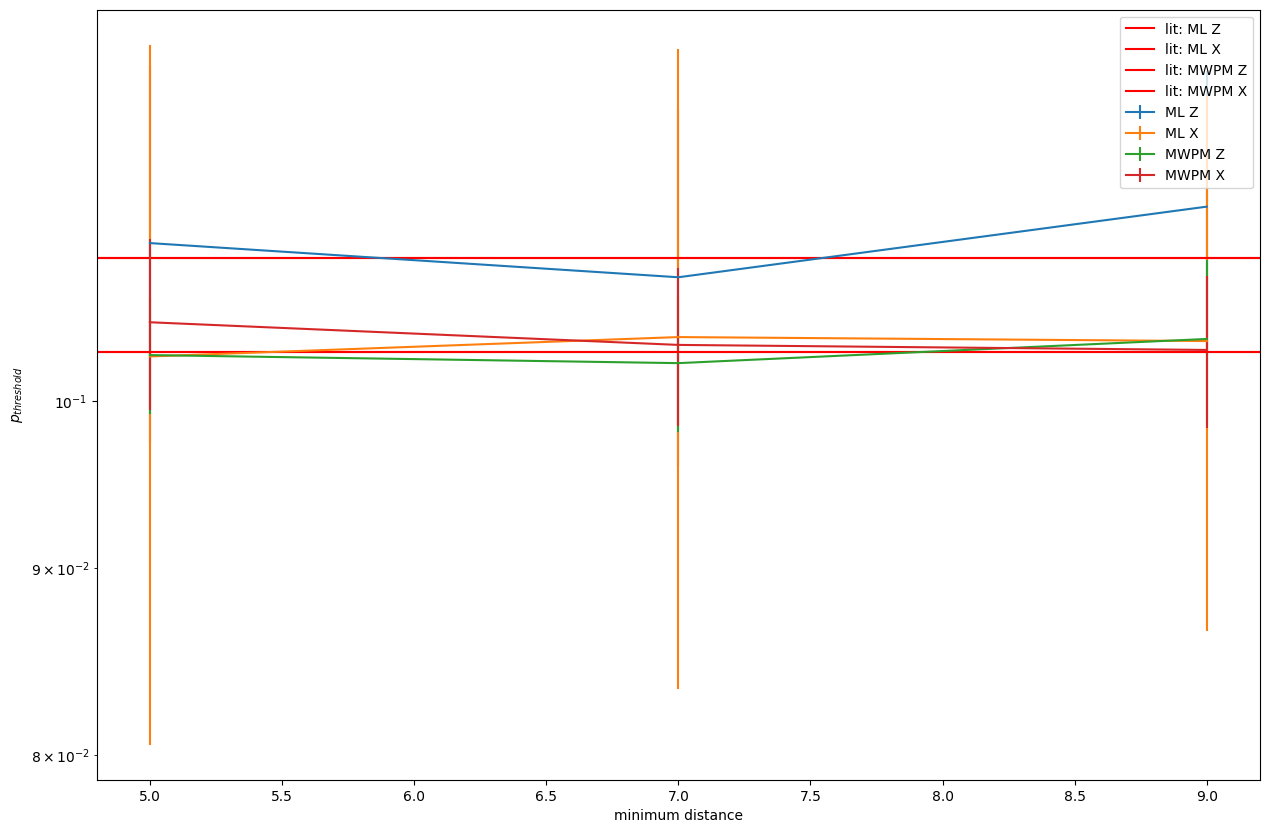

In [38]:
plt.figure(figsize=(15,10))
plt.xlabel("minimum distance")
for i in range(len(folder_names)):
    if i == 1:
        pass
        # continue
    plt.errorbar(min_distances,p_th_varied[:,i], yerr=err_p_th_varied[:,i],label=names[i])
    plt.axhline(literature[i], label="lit: "+ names[i], color= "red" )
plt.ylabel("$p_{threshold}$")
plt.yscale("log")
plt.legend()
plt.show()